# GWE–VSC reactive transport: visual analysis

This notebook visualizes the executed `GWE_VSC_Reactive` case. It connects the temperature front, VSC viscosity, effective hydraulic conductivity, kinetic mineral dissolution, porosity feedback, solute transport, and the solved seepage field.

In [2]:
import os
import sys
from pathlib import Path

sys.dont_write_bytecode = True
_name = "GWE_VSC_Reactive"
_candidates = [
    p for base in (Path.cwd(), *Path.cwd().parents) for p in (base, base / "examples" / _name)
]
CASE_DIR = next(
    (p.resolve() for p in _candidates if p.name == _name and (p / "modflow_model.py").is_file()),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{_name} from {Path.cwd()}")
os.chdir(CASE_DIR)
sys.path.insert(0, str(CASE_DIR))
__file__ = str(CASE_DIR / "plot.ipynb")
from modflow_model import runtime_path

OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"

# Saved numerical outputs are distributed losslessly; solver logs are omitted.
import zipfile

for _kind in ("output", "simulation"):
    _base = CASE_DIR / _kind
    for _archive in sorted(_base.glob("saved_results*.zip")):
        with zipfile.ZipFile(_archive) as _zip:
            for _member in _zip.infolist():
                _target = (_base / _member.filename).resolve()
                if not _target.is_relative_to(_base.resolve()):
                    raise ValueError("Archive member escapes the case directory")
                if not _target.exists():
                    _zip.extract(_member, _base)

## tl;dr

- The hot boundary produces a 20–60 °C temperature field and lowers viscosity from about 1.002 to 0.462 mPa·s.
- VSC raises the local effective K to about 2.40 m/day, while reaction-driven porosity change raises reference K only to about 1.11 m/day.
- The hottest cells dissolve the most `ThermalMineral`, generate more `Product`, and increase porosity.
- `temperature_for_flow` is one explicit-coupling step behind the temperature used by PhreeqcRM reactions.

## Context & Methods

The notebook reads NumPy outputs written by MF6PQC plus the MODFLOW head file. Three figures are saved under `output/figures/` as publication-quality PNG files.

### Key Assumptions

- MODFLOW length and time units are metres and days.
- GWE temperature and PhreeqcRM temperature are degrees Celsius.
- VSC viscosity is shown in mPa·s after multiplying its SI value by 1000.
- ThermalSNIA is explicit: feedback calculated at one endpoint affects flow during the following step.

In [3]:
import json
from pathlib import Path

import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

cwd = Path.cwd().resolve()
candidates = [cwd, cwd / "examples" / "GWE_VSC_Reactive"]
EXAMPLE_DIR = next(
    (path for path in candidates if (path / "output" / "results.npy").is_file()),
    None,
)
if EXAMPLE_DIR is None:
    raise FileNotFoundError("Run examples/GWE_VSC_Reactive/run.py before executing this notebook.")
OUTPUT_DIR = EXAMPLE_DIR / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EXAMPLE_DIR

WindowsPath('D:/Archives/code/mf6pqc/examples/GWE_VSC_Reactive')

## Data

Load all fields on the common MF6PQC result-time axis and summarize their final ranges.

In [4]:
results = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8").splitlines()
times = np.load(OUTPUT_DIR / "results_times.npy")
temperature = np.load(OUTPUT_DIR / "results_temperature.npy")
temperature_for_flow = np.load(OUTPUT_DIR / "results_temperature_for_flow.npy")
viscosity = np.load(OUTPUT_DIR / "results_viscosity.npy")
reference_k = np.load(OUTPUT_DIR / "results_reference_K.npy")
effective_k = np.load(OUTPUT_DIR / "results_effective_K.npy")
porosity = np.load(OUTPUT_DIR / "results_porosity.npy")
manifest = json.loads((OUTPUT_DIR / "results_manifest.json").read_text(encoding="utf-8"))


def selected_output(name):
    return results[:, headings.index(name), :]


tracer = selected_output("Tracer")
product = selected_output("Product")
mineral = selected_output("ThermalMineral")
arrhenius_factor = selected_output("ArrheniusFactor")
mineral_loss = mineral[0] - mineral

ncell = results.shape[2]
cell_width_m = 0.25
x = (np.arange(ncell) + 0.5) * cell_width_m

summary = pd.DataFrame(
    {
        "field": [
            "Temperature (deg C)",
            "Viscosity (mPa s)",
            "Porosity",
            "Reference K (m/day)",
            "Effective K (m/day)",
        ],
        "final minimum": [
            temperature[-1].min(),
            viscosity[-1].min() * 1e3,
            porosity[-1].min(),
            reference_k[-1].min(),
            effective_k[-1].min(),
        ],
        "final maximum": [
            temperature[-1].max(),
            viscosity[-1].max() * 1e3,
            porosity[-1].max(),
            reference_k[-1].max(),
            effective_k[-1].max(),
        ],
    }
)
summary.round(6)

,field,final minimum,final maximum
0,Temperature (deg C),20.000000,60.000000
1,Viscosity (mPa s),0.462214,1.001600
2,Porosity,0.301019,0.308086
3,Reference K (m/day),1.012847,1.106150
4,Effective K (m/day),1.012847,2.396987


In [5]:
# Recheck the two defining cross-solver contracts before plotting.
viscosity_reference = 1.0016e-3
vsc_error = np.max(np.abs(effective_k - reference_k * viscosity_reference / viscosity))
thermal_lag_error = np.max(np.abs(temperature_for_flow[1:] - temperature[:-1]))
arrhenius_expected = np.exp(-45000.0 / 8.314462618 * (1.0 / (temperature + 273.15) - 1.0 / 293.15))
reaction_temperature_error = np.max(np.abs(arrhenius_factor - arrhenius_expected))
assert vsc_error < 1e-10
assert thermal_lag_error < 1e-10
assert reaction_temperature_error < 1e-9
pd.Series(
    {
        "maximum VSC identity error": vsc_error,
        "maximum explicit-lag error": thermal_lag_error,
        "maximum GWE-to-reaction temperature error": reaction_temperature_error,
    }
)

maximum VSC identity error                   4.440892e-16
maximum explicit-lag error                   0.000000e+00
maximum GWE-to-reaction temperature error    0.000000e+00
dtype: float64

## Results

### 1. Coupled endpoint profiles

The first figure separates reaction-driven reference K from the much larger viscosity-driven effective K response.

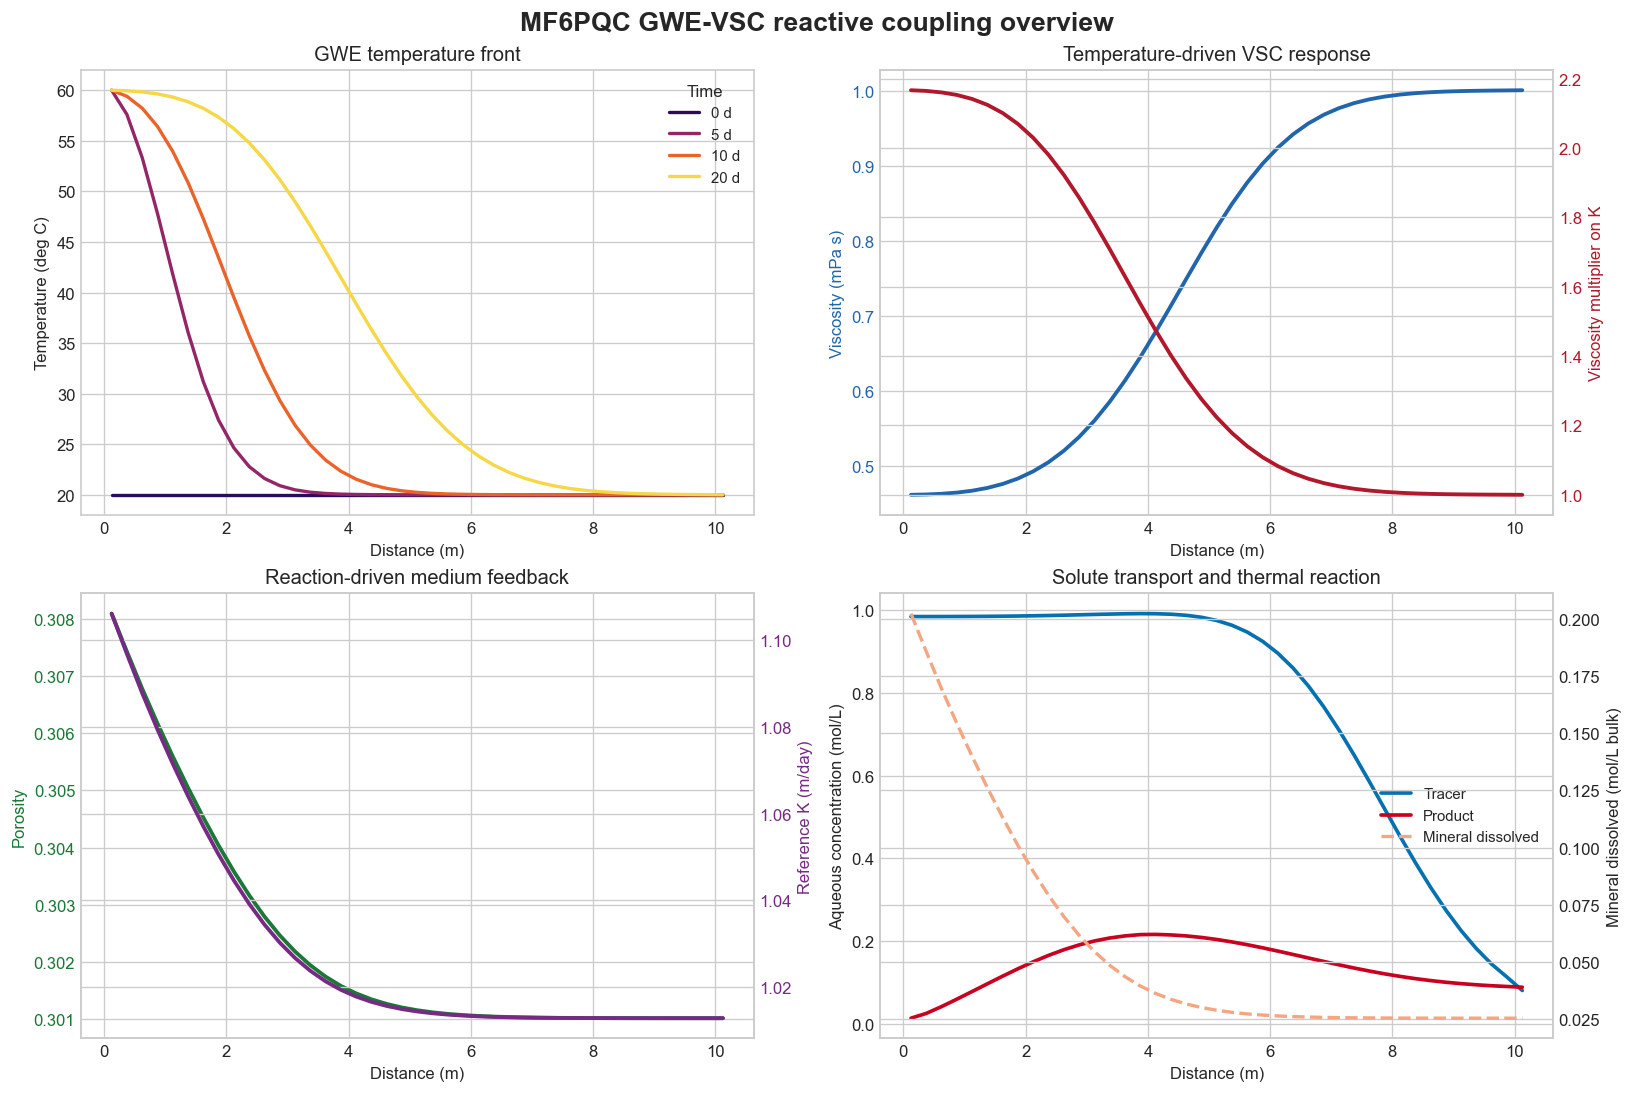

In [6]:
profile_times = [0.0, 5.0, 10.0, 20.0]
profile_indices = [int(np.argmin(np.abs(times - value))) for value in profile_times]
colors = plt.cm.inferno(np.linspace(0.15, 0.9, len(profile_indices)))

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), constrained_layout=True)
for index, color in zip(profile_indices, colors, strict=False):
    axes[0, 0].plot(x, temperature[index], color=color, lw=2, label=f"{times[index]:g} d")
axes[0, 0].set(title="GWE temperature front", xlabel="Distance (m)", ylabel="Temperature (deg C)")
axes[0, 0].legend(title="Time")

axes[0, 1].plot(x, viscosity[-1] * 1e3, color="#2166ac", lw=2.3, label="Viscosity")
axes[0, 1].set(
    title="Temperature-driven VSC response", xlabel="Distance (m)", ylabel="Viscosity (mPa s)"
)
axes[0, 1].yaxis.label.set_color("#2166ac")
axes[0, 1].tick_params(axis="y", labelcolor="#2166ac")
axis_k_ratio = axes[0, 1].twinx()
axis_k_ratio.plot(
    x, effective_k[-1] / reference_k[-1], color="#b2182b", lw=2.3, label="K effective / K reference"
)
axis_k_ratio.set_ylabel("Viscosity multiplier on K", color="#b2182b")
axis_k_ratio.tick_params(axis="y", labelcolor="#b2182b")

axes[1, 0].plot(x, porosity[-1], color="#1b7837", lw=2.3, label="Porosity")
axes[1, 0].set(title="Reaction-driven medium feedback", xlabel="Distance (m)", ylabel="Porosity")
axes[1, 0].yaxis.label.set_color("#1b7837")
axes[1, 0].tick_params(axis="y", labelcolor="#1b7837")
axis_reference_k = axes[1, 0].twinx()
axis_reference_k.plot(x, reference_k[-1], color="#762a83", lw=2.3, label="Reference K")
axis_reference_k.set_ylabel("Reference K (m/day)", color="#762a83")
axis_reference_k.tick_params(axis="y", labelcolor="#762a83")

axes[1, 1].plot(x, tracer[-1], color="#0571b0", lw=2.2, label="Tracer")
axes[1, 1].plot(x, product[-1], color="#ca0020", lw=2.2, label="Product")
axes[1, 1].set(
    title="Solute transport and thermal reaction",
    xlabel="Distance (m)",
    ylabel="Aqueous concentration (mol/L)",
)
axis_mineral = axes[1, 1].twinx()
axis_mineral.plot(x, mineral_loss[-1], color="#f4a582", lw=2.0, ls="--", label="Mineral dissolved")
axis_mineral.set_ylabel("Mineral dissolved (mol/L bulk)")
lines_a, labels_a = axes[1, 1].get_legend_handles_labels()
lines_b, labels_b = axis_mineral.get_legend_handles_labels()
axes[1, 1].legend(lines_a + lines_b, labels_a + labels_b, loc="center right")

fig.suptitle("MF6PQC GWE-VSC reactive coupling overview", fontsize=16, fontweight="bold")
plt.show()

### 2. Space–time evolution

These heatmaps show how the GWE front propagates and how VSC transfers that field into viscosity and effective K.

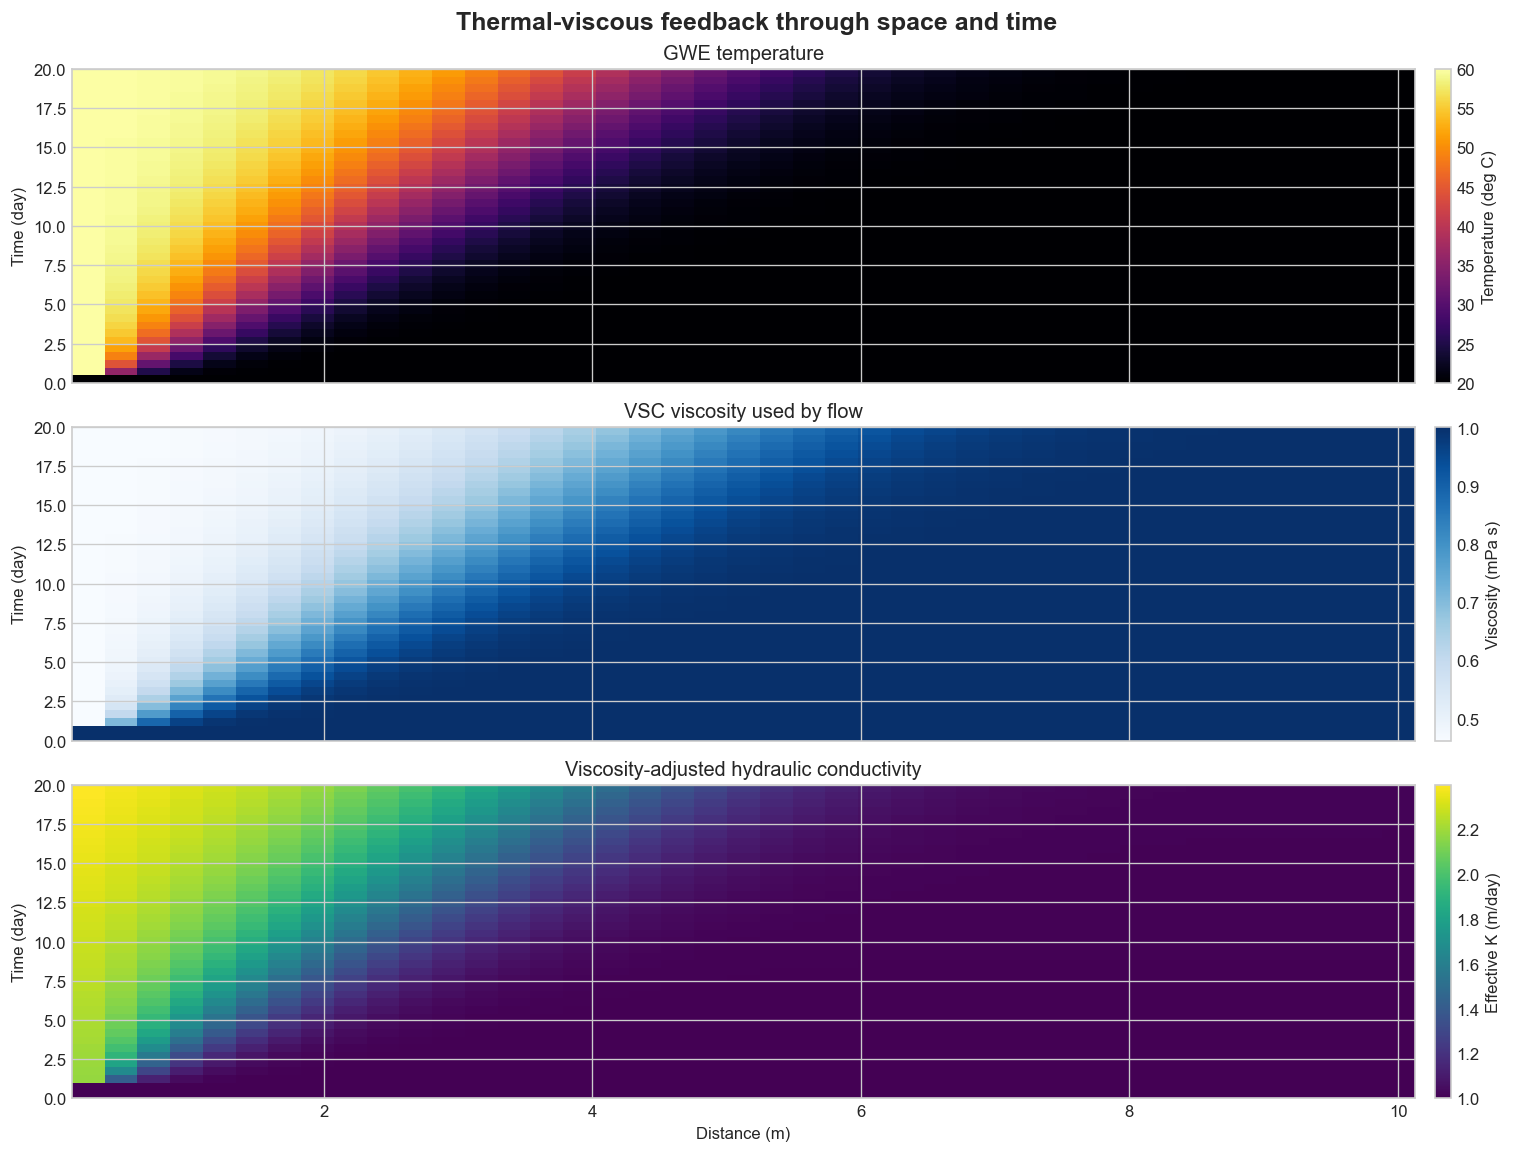

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12.5, 9.5), sharex=True, constrained_layout=True)
heatmaps = [
    (temperature, "inferno", "Temperature (deg C)", "GWE temperature"),
    (viscosity * 1e3, "Blues", "Viscosity (mPa s)", "VSC viscosity used by flow"),
    (effective_k, "viridis", "Effective K (m/day)", "Viscosity-adjusted hydraulic conductivity"),
]
for axis, (values, cmap, colorbar_label, title) in zip(axes, heatmaps, strict=False):
    image = axis.imshow(
        values,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        extent=[x[0], x[-1], times[0], times[-1]],
        interpolation="nearest",
    )
    axis.set_ylabel("Time (day)")
    axis.set_title(title)
    fig.colorbar(image, ax=axis, pad=0.015, label=colorbar_label)
axes[-1].set_xlabel("Distance (m)")
fig.suptitle("Thermal-viscous feedback through space and time", fontsize=15, fontweight="bold")
plt.show()

### 3. Seepage and feedback attribution

The last figure connects the final head field to the two conductivity contributions and shows that hotter cells undergo greater mineral loss.

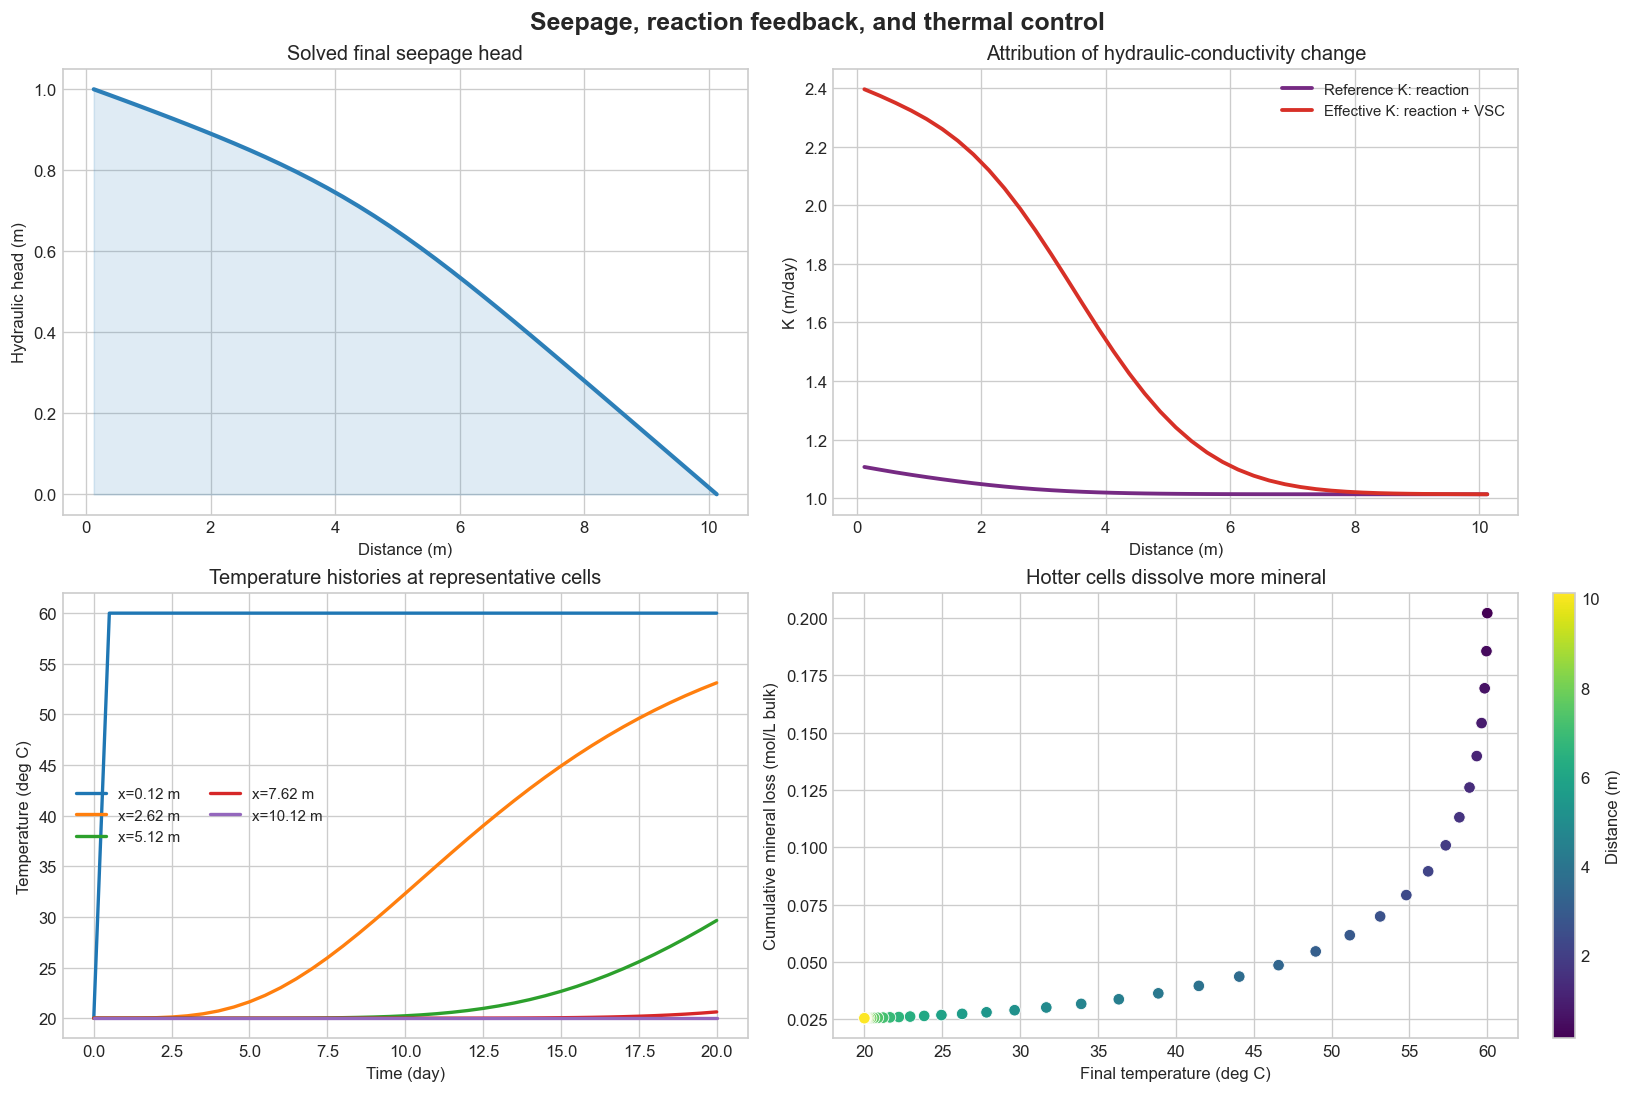

In [8]:
head_file = flopy.utils.HeadFile(EXAMPLE_DIR / "simulation" / "gwf_model.hds")
final_head = np.asarray(head_file.get_data(totim=float(times[-1]))).ravel()
representative_cells = [0, 10, 20, 30, 40]

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), constrained_layout=True)
axes[0, 0].plot(x, final_head, color="#2c7fb8", lw=2.5)
axes[0, 0].fill_between(x, final_head, alpha=0.15, color="#2c7fb8")
axes[0, 0].set(
    title="Solved final seepage head", xlabel="Distance (m)", ylabel="Hydraulic head (m)"
)

axes[0, 1].plot(x, reference_k[-1], color="#762a83", lw=2.3, label="Reference K: reaction")
axes[0, 1].plot(x, effective_k[-1], color="#d73027", lw=2.3, label="Effective K: reaction + VSC")
axes[0, 1].set(
    title="Attribution of hydraulic-conductivity change", xlabel="Distance (m)", ylabel="K (m/day)"
)
axes[0, 1].legend()

for cell in representative_cells:
    axes[1, 0].plot(times, temperature[:, cell], lw=2, label=f"x={x[cell]:.2f} m")
axes[1, 0].set(
    title="Temperature histories at representative cells",
    xlabel="Time (day)",
    ylabel="Temperature (deg C)",
)
axes[1, 0].legend(ncol=2)

scatter = axes[1, 1].scatter(
    temperature[-1], mineral_loss[-1], c=x, cmap="viridis", s=48, edgecolor="white", linewidth=0.5
)
axes[1, 1].set(
    title="Hotter cells dissolve more mineral",
    xlabel="Final temperature (deg C)",
    ylabel="Cumulative mineral loss (mol/L bulk)",
)
fig.colorbar(scatter, ax=axes[1, 1], label="Distance (m)")

fig.suptitle("Seepage, reaction feedback, and thermal control", fontsize=15, fontweight="bold")
plt.show()

## 数值核对

只检查已有结果，不启动模型。

In [9]:
"""Quantitative checks for every coupling arrow in the thermal example."""


import json
import sys
from pathlib import Path

import flopy
import numpy as np
from modflow_model import BASE_K, POROSITY, VISCOSITY_REFERENCE


def validate_saved_results() -> None:

    OUTPUT = runtime_path(__file__, "output")

    results = np.load(OUTPUT / "results.npy")

    headings = (OUTPUT / "results_headings.txt").read_text(encoding="utf-8").splitlines()

    times = np.load(OUTPUT / "results_times.npy")

    temperature = np.load(OUTPUT / "results_temperature.npy")

    temperature_for_flow = np.load(OUTPUT / "results_temperature_for_flow.npy")

    viscosity = np.load(OUTPUT / "results_viscosity.npy")

    reference_k = np.load(OUTPUT / "results_reference_K.npy")

    effective_k = np.load(OUTPUT / "results_effective_K.npy")

    porosity = np.load(OUTPUT / "results_porosity.npy")

    manifest = json.loads((OUTPUT / "results_manifest.json").read_text(encoding="utf-8"))

    def field(name: str) -> np.ndarray:
        return results[:, headings.index(name), :]

    assert np.all(np.diff(times) > 0.0)

    assert temperature.shape == porosity.shape == reference_k.shape == effective_k.shape

    assert float(np.max(temperature[-1])) > 50.0

    assert float(np.ptp(temperature[-1])) > 20.0

    np.testing.assert_allclose(temperature_for_flow[1:], temperature[:-1], atol=1.0e-10)

    arrhenius_expected = np.exp(
        -45000.0 / 8.314462618 * (1.0 / (temperature + 273.15) - 1.0 / 293.15)
    )

    np.testing.assert_allclose(
        field("ArrheniusFactor"), arrhenius_expected, rtol=2.0e-10, atol=1.0e-12
    )

    np.testing.assert_allclose(
        effective_k,
        reference_k * VISCOSITY_REFERENCE / viscosity,
        rtol=2.0e-10,
        atol=1.0e-12,
    )

    assert float(np.ptp(viscosity[-1])) > 1.0e-4

    assert float(np.ptp(effective_k[-1])) > 0.1

    assert float(np.max(np.abs(porosity[-1] - POROSITY))) > 1.0e-5

    assert float(np.max(np.abs(reference_k[-1] - BASE_K))) > 1.0e-4

    phi = porosity[-2]

    expected_reference = BASE_K * (
        (phi**3 / (1.0 - phi) ** 2) / (POROSITY**3 / (1.0 - POROSITY) ** 2)
    )

    np.testing.assert_allclose(reference_k[-1], expected_reference, rtol=2.0e-9)

    tracer = field("Tracer")

    mineral = field("ThermalMineral")

    product = field("Product")

    assert tracer[-1, 0] > 0.9

    assert np.count_nonzero(tracer[-1] > 1.0e-3) > 5

    assert float(np.ptp(mineral[-1])) > 1.0e-4

    assert float(np.max(product[-1])) > 1.0e-3

    head_file = flopy.utils.HeadFile(runtime_path(__file__, "simulation") / "gwf_model.hds")

    heads = np.asarray(head_file.get_data()).ravel()

    assert np.all(np.isfinite(heads))

    assert heads[0] > heads[-1]

    assert float(np.ptp(heads)) > 0.9

    assert manifest["has_energy"]

    assert manifest["has_porosity_and_k"]

    assert manifest["run"]["modflow_convergence_failures"] == []

    print("All GWE/VSC/reactive coupling checks passed.")


validate_saved_results()

All GWE/VSC/reactive coupling checks passed.
